## Generate Insertion Figure

### Attention

In [1]:
import numpy as np

data = np.load("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention/02F4A1FB_left_curve.npy", allow_pickle=True).item()

percentages = np.array(data["percentages"])
confidences = np.array(data["confidences"])

print(percentages.shape, confidences.shape)

(21,) (21, 3)


#### Overall

curves shape: (116, 21, 3)
percentages shape: (21,)


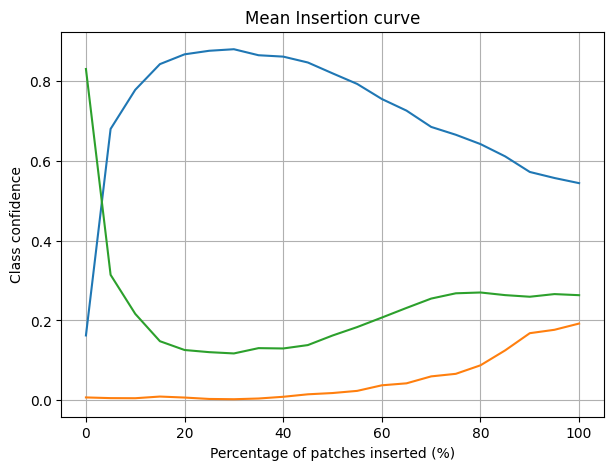

-----------------------
-----------------------
-----------------------


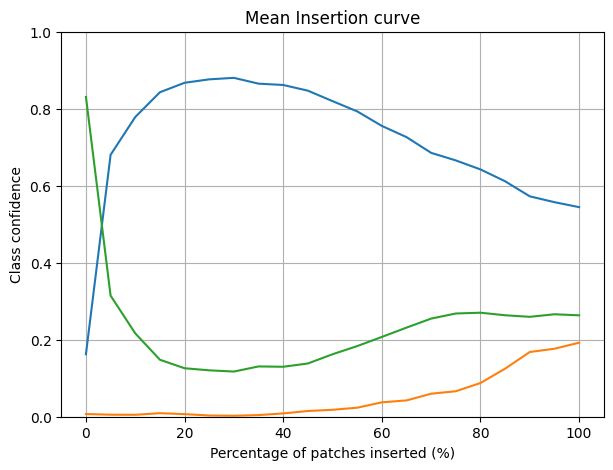

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()




curves shape: (116, 21)
percentages shape: (21,)


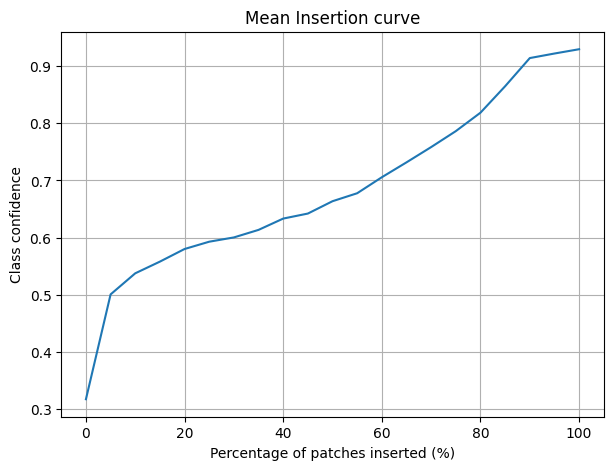

-----------------------
-----------------------
-----------------------


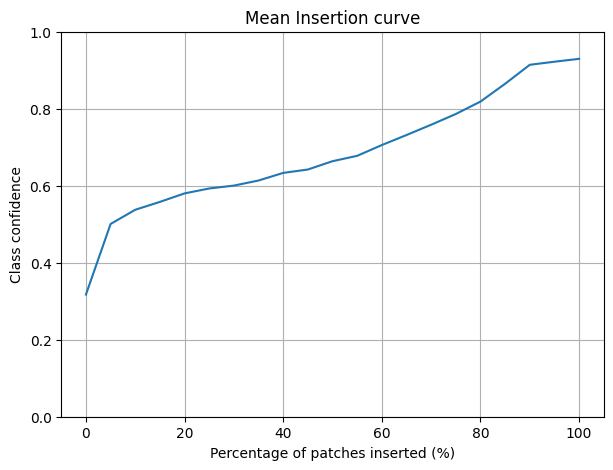

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()




#### Each Class

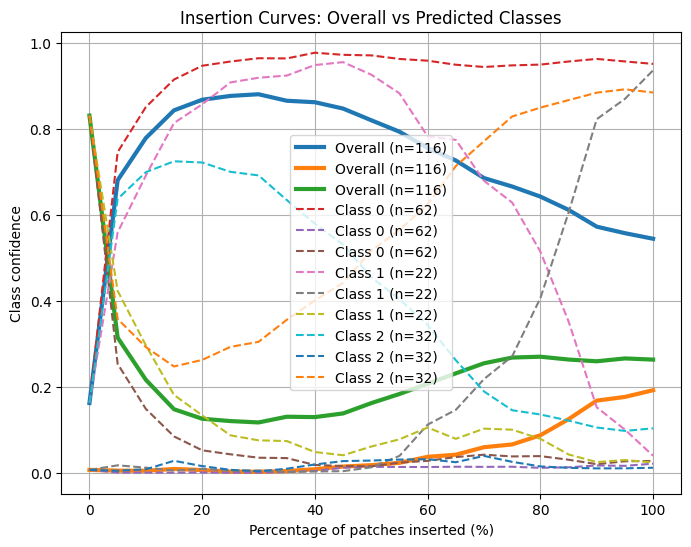

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_attention.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches inserted (%)")
plt.ylabel("Class confidence")
plt.title("Insertion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


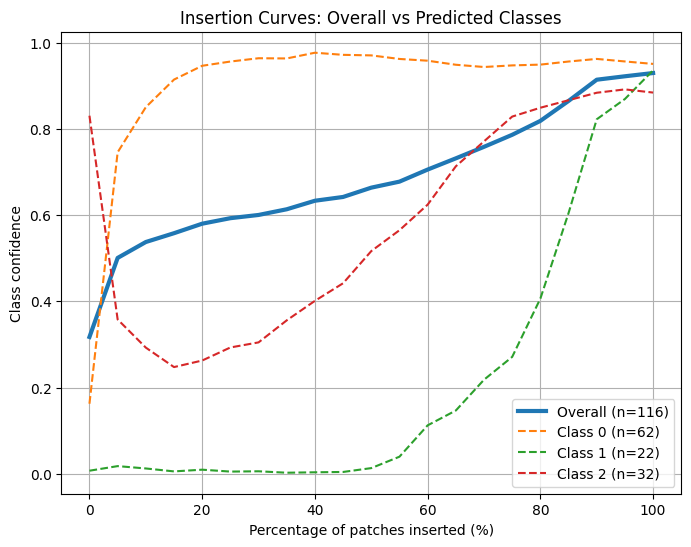

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_attention.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches inserted (%)")
plt.ylabel("Class confidence")
plt.title("Insertion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


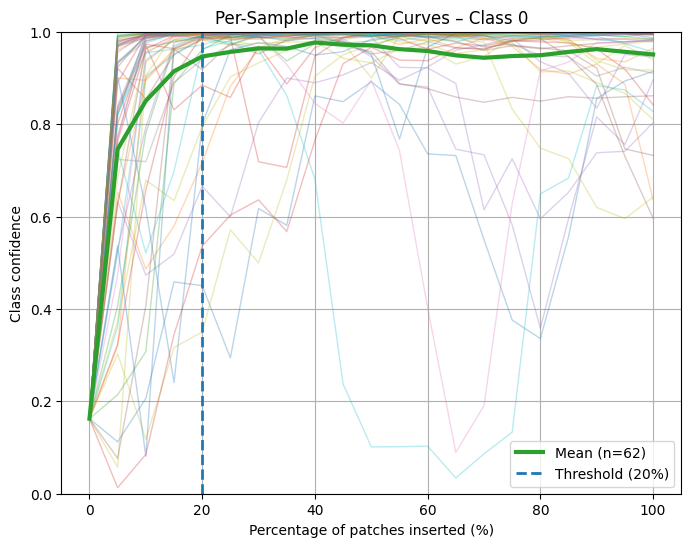

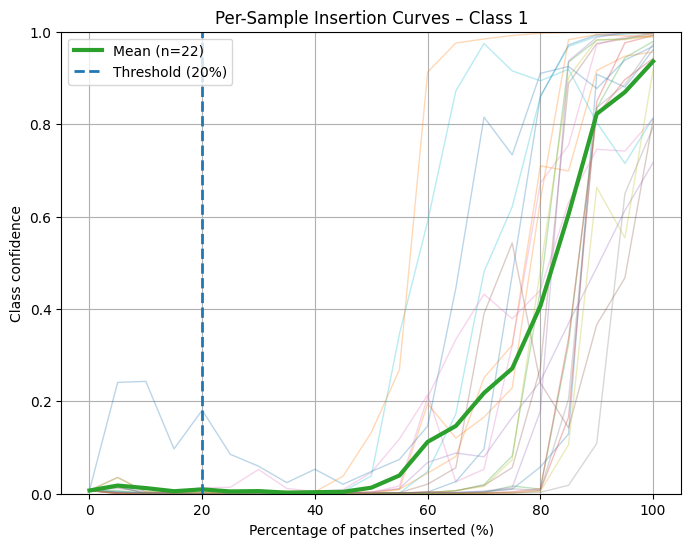

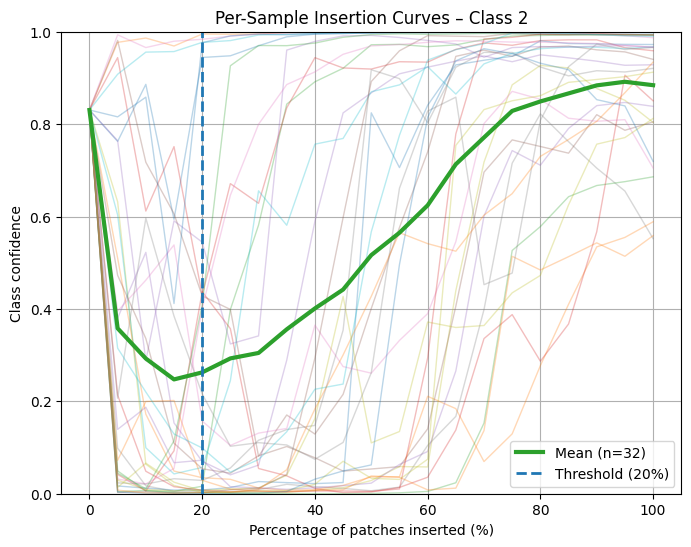

In [13]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    # Vertical threshold at 20%
    plt.axvline(
        x=20,
        linestyle="--",
        linewidth=2,
        label="Threshold (20%)"
    )

    plt.xlabel("Percentage of patches inserted (%)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Insertion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


### Attention Rollout

In [14]:
import numpy as np

data = np.load("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/attention_mask/02F4A1FB_left_curve_attention_mask.npy", allow_pickle=True).item()

percentages = np.array(data["percentages"])
confidences = np.array(data["confidences"])

print(percentages.shape, confidences.shape)

(21,) (21, 3)


#### Overall

curves shape: (116, 21, 3)
percentages shape: (21,)


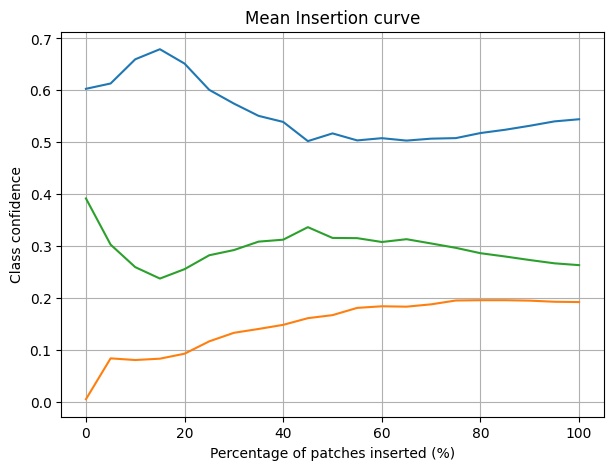

-----------------------
-----------------------
-----------------------


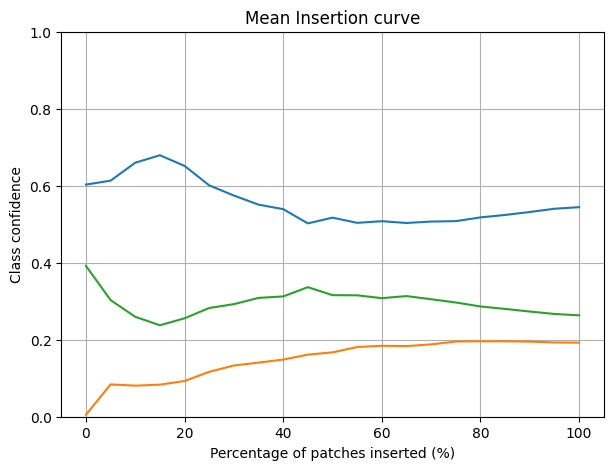

In [15]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/attention_mask") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()




#### Each Class

#### Overall - Black

curves shape: (116, 21, 3)
percentages shape: (21,)


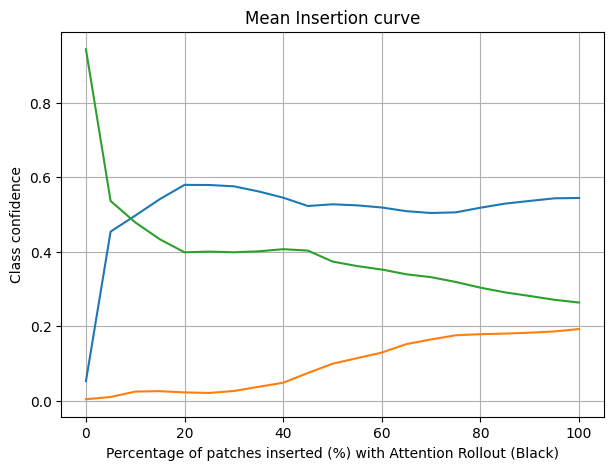

-----------------------
-----------------------
-----------------------


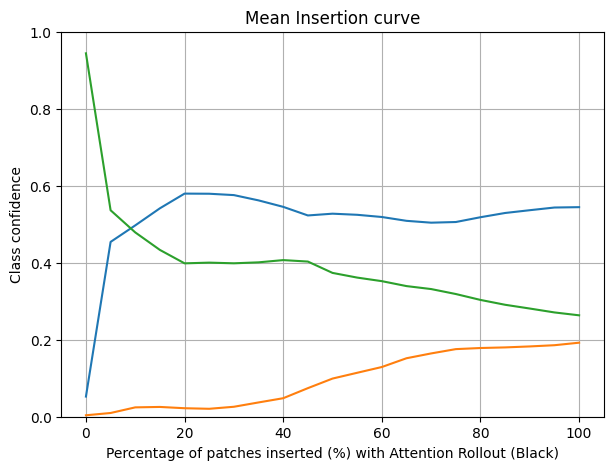

In [19]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/black") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()




curves shape: (116, 21)
percentages shape: (21,)


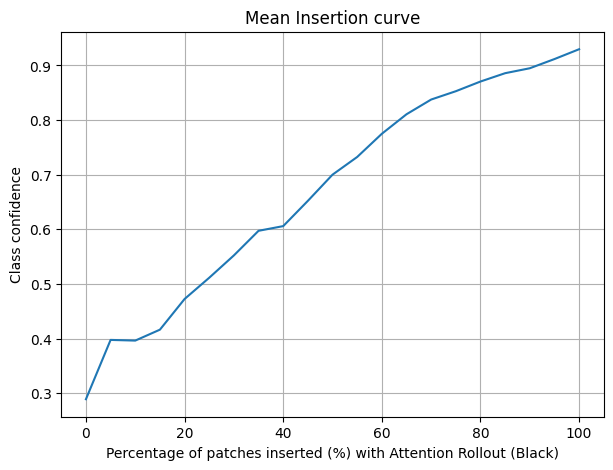

-----------------------
-----------------------
-----------------------


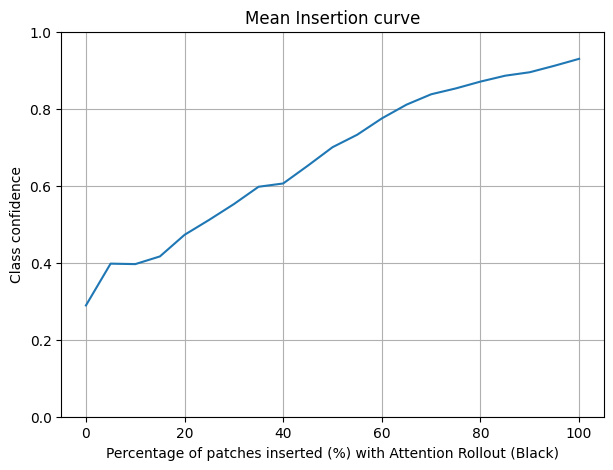

In [20]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/black") 
curves = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves.append(data["predicted_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves = np.array(curves)
mean_conf = curves.mean(axis=0)

print("curves shape:", curves.shape)
print("percentages shape:", np.array(percentages).shape)


x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()


print ("-----------------------")
print ("-----------------------")
print ("-----------------------")


plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylim(0, 1)
plt.ylabel("Class confidence")
plt.title("Mean Insertion curve")
plt.grid(True)
plt.show()




#### Each Class

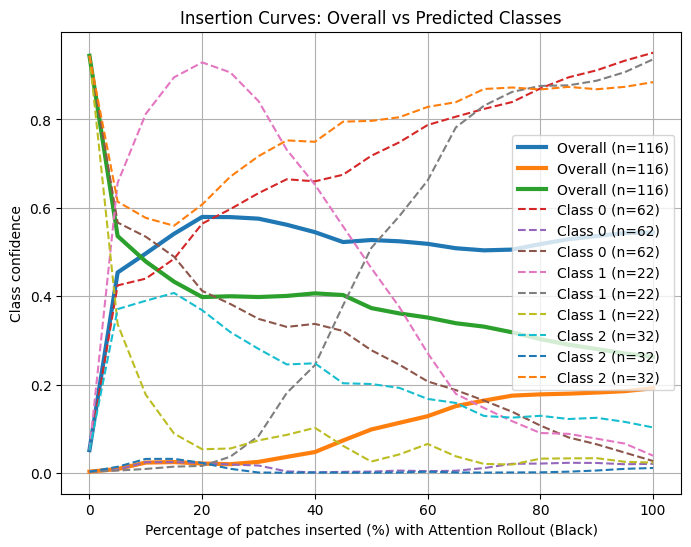

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/black")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_attention_rollout_black.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylabel("Class confidence")
plt.title("Insertion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


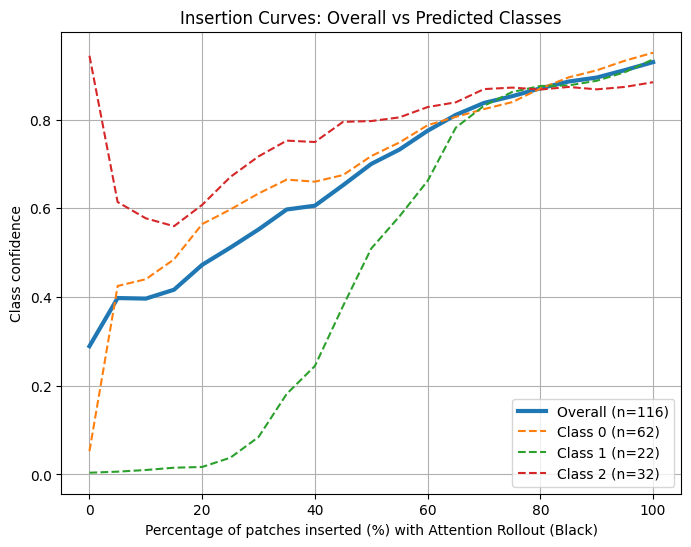

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/black")
csv_path = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_attention_rollout_black.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace("_curve_black", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
plt.ylabel("Class confidence")
plt.title("Insertion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


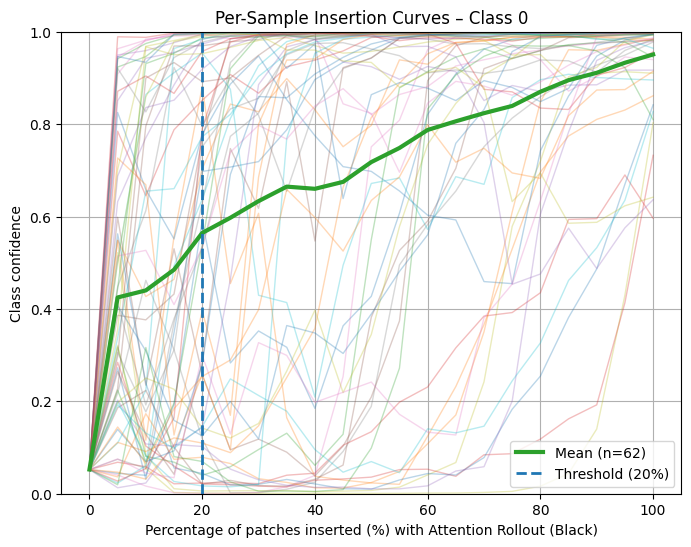

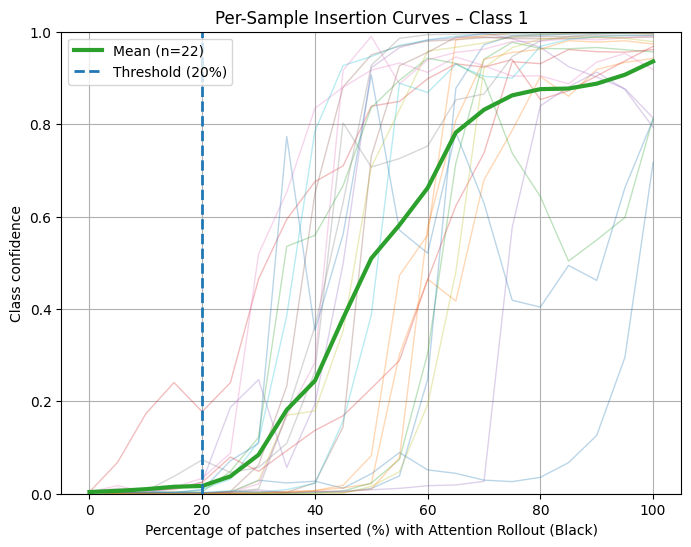

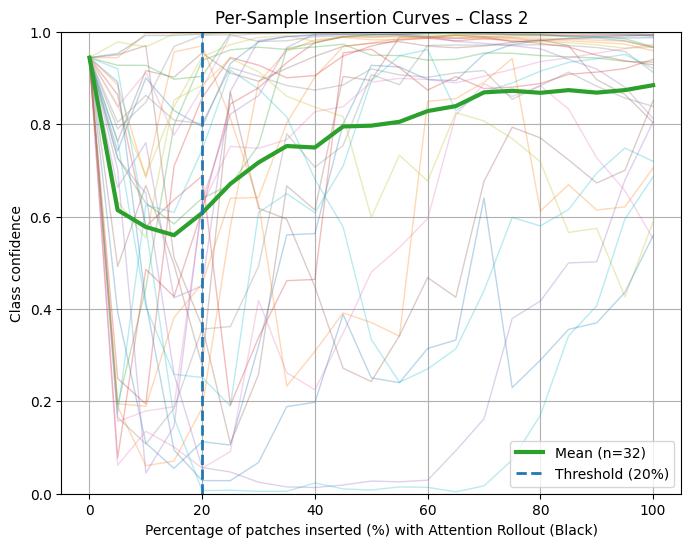

In [23]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    # Vertical threshold at 20%
    plt.axvline(
        x=20,
        linestyle="--",
        linewidth=2,
        label="Threshold (20%)"
    )

    plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Insertion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


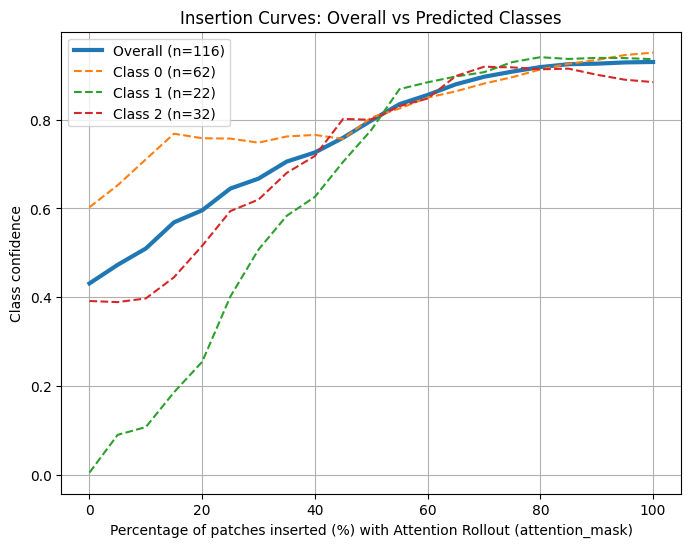

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

method = "attention_mask"

# Paths
curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_curves/attention_rollout/{method}")
csv_path = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/insertion/insertion_attention_rollout_{method}.csv")    

# Load CSV
df = pd.read_csv(csv_path)
uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

all_curves = []
class_curves = {}
percentages = None

# Load curves
for f in curve_dir.glob("*.npy"):
    uid = f.stem.replace(f"_curve_{method}", "")
    
    if uid not in uid_to_class:
        continue

    data = np.load(f, allow_pickle=True).item()
    confidences = data["predicted_confidences"]
    
    all_curves.append(confidences)
    
    cls = uid_to_class[uid]
    if cls not in class_curves:
        class_curves[cls] = []
    class_curves[cls].append(confidences)
    
    if percentages is None:
        percentages = data["percentages"]

# Safety check
if len(all_curves) == 0:
    raise ValueError("No matching curves found.")

# Convert to numpy
all_curves = np.array(all_curves)
overall_mean = all_curves.mean(axis=0)

# Plot
x_percent = np.array(percentages) * 100
plt.figure(figsize=(8, 6))

# Overall curve (thicker line)
plt.plot(
    x_percent,
    overall_mean,
    linewidth=3,
    label=f"Overall (n={len(all_curves)})"
)

# Per-class curves
for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linestyle="--",
        label=f"Class {cls} (n={len(curves)})"
    )

plt.xlabel(f"Percentage of patches inserted (%) with Attention Rollout ({method})")
plt.ylabel("Class confidence")
plt.title("Insertion Curves: Overall vs Predicted Classes")
plt.legend()
plt.grid(True)
plt.show()


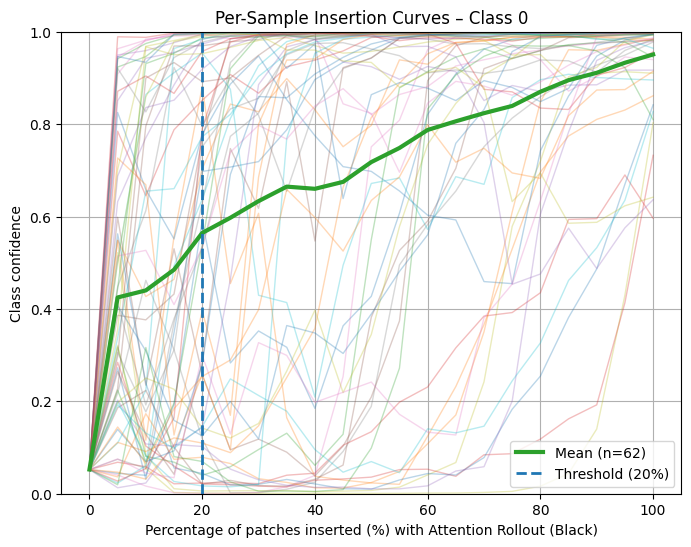

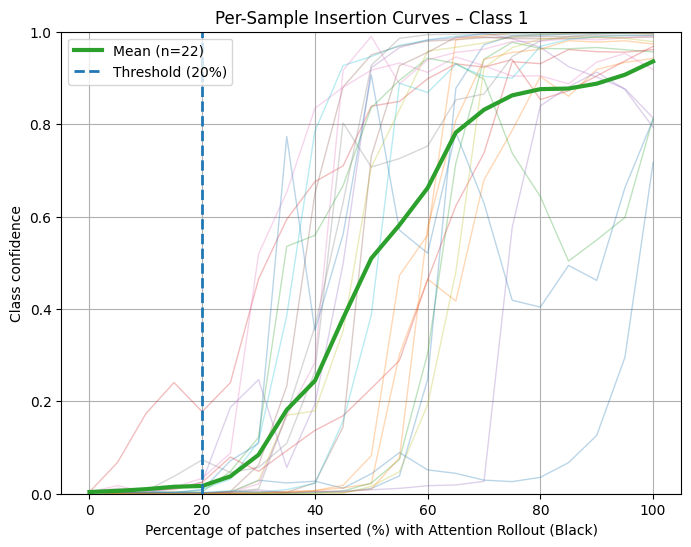

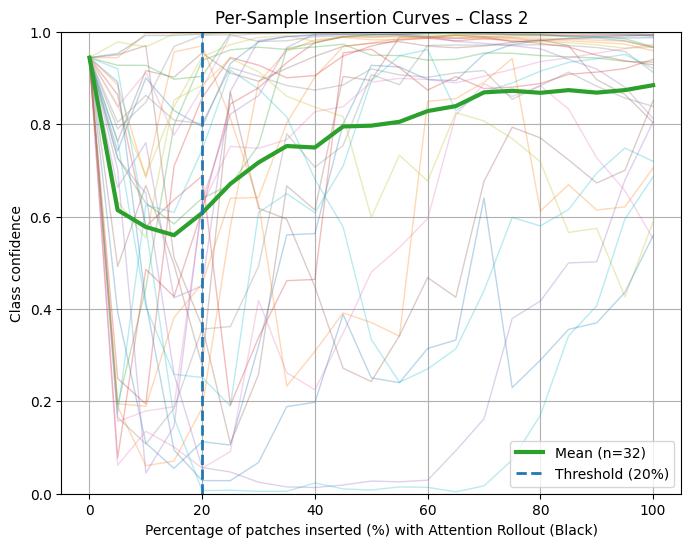

In [ ]:
# --- Plot per-sample curves for every class ---

x_percent = np.array(percentages) * 100

for cls, curves in sorted(class_curves.items()):
    curves = np.array(curves)

    plt.figure(figsize=(8, 6))

    # Plot individual sample curves (light lines)
    for curve in curves:
        plt.plot(
            x_percent,
            curve,
            alpha=0.3,
            linewidth=1
        )

    # Plot mean curve (bold)
    mean_curve = curves.mean(axis=0)
    plt.plot(
        x_percent,
        mean_curve,
        linewidth=3,
        label=f"Mean (n={len(curves)})"
    )

    # Vertical threshold at 20%
    plt.axvline(
        x=20,
        linestyle="--",
        linewidth=2,
        label="Threshold (20%)"
    )

    plt.xlabel("Percentage of patches inserted (%) with Attention Rollout (Black)")
    plt.ylabel("Class confidence")
    plt.title(f"Per-Sample Insertion Curves – Class {cls}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


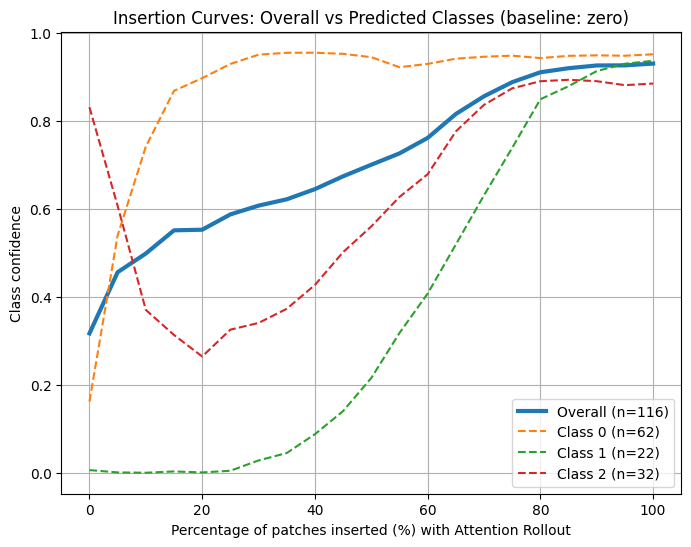

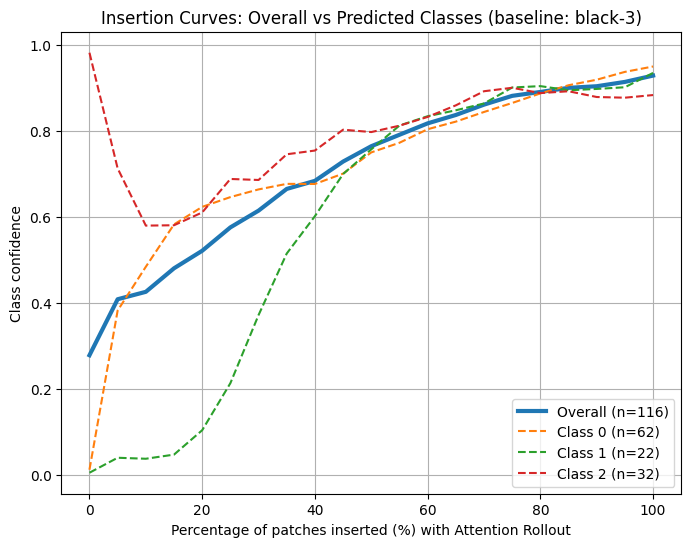

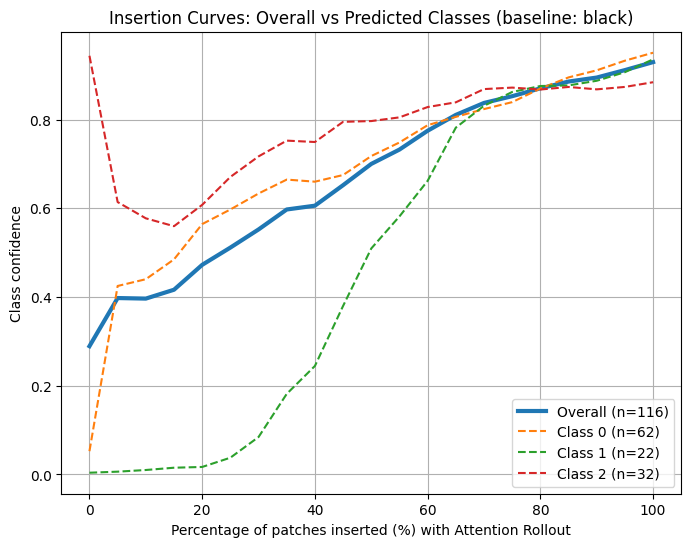

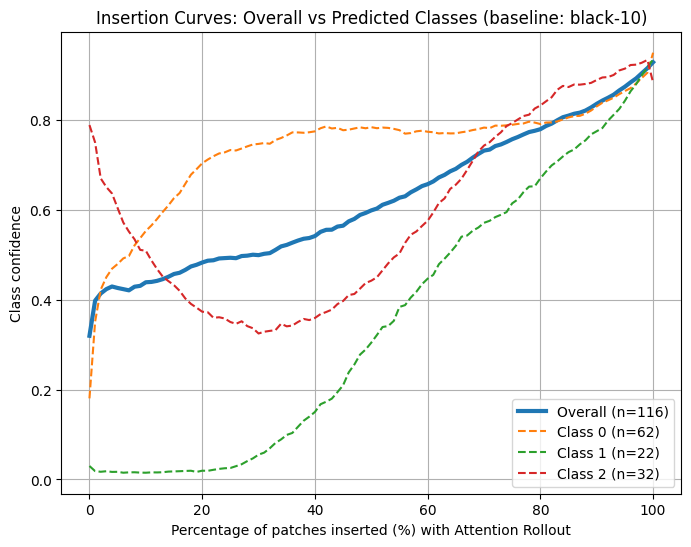

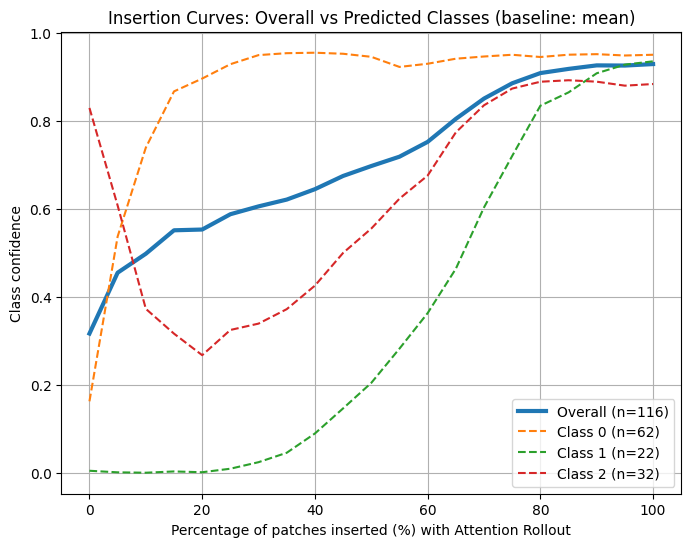

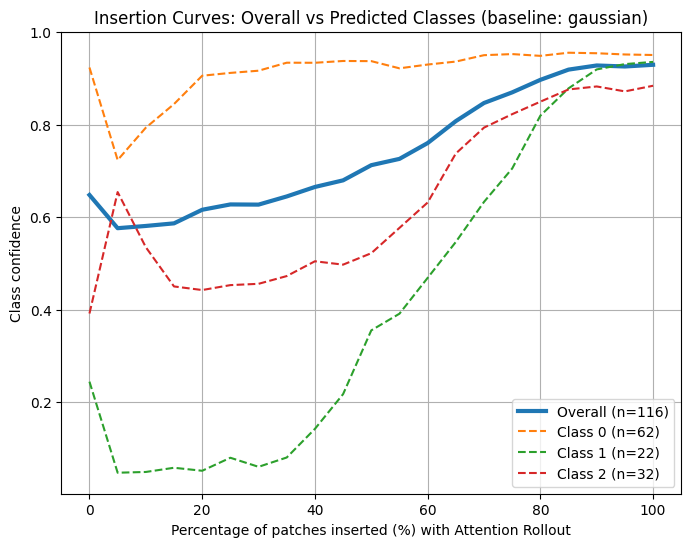

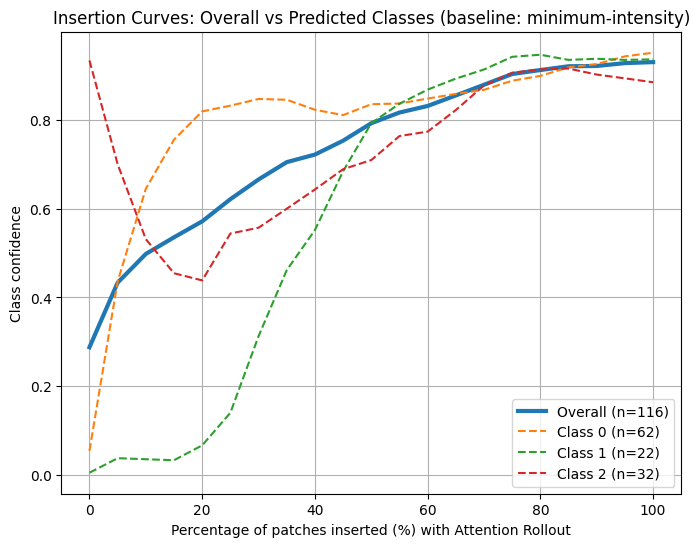

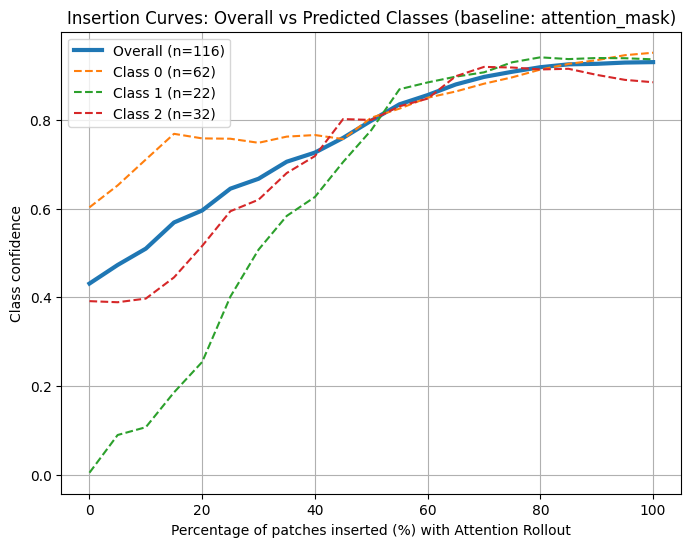

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


BASE_DIR = Path(
    "/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/"
    "evaluation_results/insertion"
)

BASELINES = {
    "zero": "zero",
    "black-3": "black-3",
    "black-5": "black",
    "black-10": "black-10",
    "mean": "mean",
    "gaussian": "gaussian",
    "minimum-intensity": "minimum-intensity",
    "attention_mask": "attention_mask",
}

for baseline in BASELINES.values():
    curve_dir = BASE_DIR / "insertion_curves" / "attention_rollout" / baseline
    csv_path = BASE_DIR /  f"insertion_attention_rollout_{baseline}.csv"



    # Load CSV
    df = pd.read_csv(csv_path)
    uid_to_class = dict(zip(df["UID"], df["predicted_class"]))

    all_curves = []
    class_curves = {}
    percentages = None

    # Load curves
    for f in curve_dir.glob("*.npy"):
        if baseline == "zero":
            uid = f.stem.replace("_curve", "")
        else:
            uid = f.stem.replace(f"_curve_{baseline}", "")
        
        if uid not in uid_to_class:
            continue

        data = np.load(f, allow_pickle=True).item()
        confidences = data["predicted_confidences"]
        
        all_curves.append(confidences)
        
        cls = uid_to_class[uid]
        if cls not in class_curves:
            class_curves[cls] = []
        class_curves[cls].append(confidences)
        
        if percentages is None:
            percentages = data["percentages"]

    # Safety check
    if len(all_curves) == 0:
        raise ValueError("No matching curves found.")

    # Convert to numpy
    all_curves = np.array(all_curves)
    overall_mean = all_curves.mean(axis=0)

    # Plot
    x_percent = np.array(percentages) * 100
    plt.figure(figsize=(8, 6))

    # Overall curve (thicker line)
    plt.plot(
        x_percent,
        overall_mean,
        linewidth=3,
        label=f"Overall (n={len(all_curves)})"
    )

    # Per-class curves
    for cls, curves in sorted(class_curves.items()):
        curves = np.array(curves)
        mean_curve = curves.mean(axis=0)
        plt.plot(
            x_percent,
            mean_curve,
            linestyle="--",
            label=f"Class {cls} (n={len(curves)})"
        )

    plt.xlabel("Percentage of patches inserted (%) with Attention Rollout")
    plt.ylabel("Class confidence")
    plt.title("Insertion Curves: Overall vs Predicted Classes (baseline: {})".format(baseline))
    plt.legend()
    plt.grid(True)
    plt.show()
